# 02. EDA and Data Quality

## 1. Purpose of Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the structure, distributions, relationships, and data-quality characteristics of the training data before preprocessing and model development.

The analysis focuses on identifying useful patterns, unusual observations, missing-data patterns, and potential issues that may affect regression models.

## 2. Import Required Libraries

The required Python libraries are imported for data manipulation, numerical analysis, visualization, and project file handling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 3. Load the Raw Dataset and Training Indices

The raw dataset and the previously saved training indices are loaded to reconstruct the exact training dataset used for EDA.

In [2]:
project_root = Path.cwd().parent

data_path = project_root / "data" / "raw" / "melb_data.csv"
train_index_path = project_root / "data" / "processed" / "train_indices.csv"

df = pd.read_csv(data_path)
train_indices = pd.read_csv(train_index_path)["row_index"]

train_df = df.loc[train_indices].copy()

print("Full dataset:", df.shape)
print("Training dataset:", train_df.shape)

Full dataset: (13580, 21)
Training dataset: (10864, 21)


### Observation

The raw dataset contains 13,580 rows and 21 columns. Using the saved training indices successfully reconstructed the training dataset with 10,864 rows and 21 columns. The same fixed training split will be used throughout the EDA process.

## 4. Inspect the Training Data Structure

The training dataset is inspected for its columns, data types, and non-null counts before detailed exploratory analysis.

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10864 entries, 12796 to 7270
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         10864 non-null  object 
 1   Address        10864 non-null  object 
 2   Rooms          10864 non-null  int64  
 3   Type           10864 non-null  object 
 4   Price          10864 non-null  float64
 5   Method         10864 non-null  object 
 6   SellerG        10864 non-null  object 
 7   Date           10864 non-null  object 
 8   Distance       10864 non-null  float64
 9   Postcode       10864 non-null  float64
 10  Bedroom2       10864 non-null  float64
 11  Bathroom       10864 non-null  float64
 12  Car            10814 non-null  float64
 13  Landsize       10864 non-null  float64
 14  BuildingArea   5735 non-null   float64
 15  YearBuilt      6578 non-null   float64
 16  CouncilArea    9774 non-null   object 
 17  Lattitude      10864 non-null  float64
 18  Longtitu

### Observation

The reconstructed training dataset contains 10,864 rows and 21 columns, including 12 `float64`, 1 `int64`, and 8 `object` columns. Missing values remain in `Car`, `BuildingArea`, `YearBuilt`, and `CouncilArea`, with `BuildingArea` and `YearBuilt` having substantial missingness. The non-sequential index values are expected because the training set was created using a randomized split while preserving the original dataset indices.

## 5. Identify Numerical and Categorical Features

Numerical and categorical features require different exploratory analysis. Numerical variables will be examined through distributions, skewness, outliers, and relationships, while categorical variables will be examined through category frequencies and cardinality.

In [4]:
numerical_features = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Categorical features:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


### Observation

The training dataset contains 13 numerical columns and 8 object columns based on their current data types. `Price` is included among the numerical columns but represents the target variable rather than a predictor. Some columns require semantic consideration: `Postcode` is numerically stored but acts as a location identifier, while `Date` is stored as an object but represents temporal information. Their final treatment will be decided during feature engineering and preprocessing.

## 6. Examine the Target Variable

The distribution and descriptive statistics of `Price` are examined before analysing the predictor variables. This helps identify the target range, central tendency, variability, and possible skewness.

In [6]:
price_summary = train_df["Price"].describe()
price_skewness = train_df["Price"].skew()

print(
    price_summary.to_string(
        float_format=lambda value: f"{value:,.2f}"
    )
)

print(f"\nPrice skewness: {price_skewness:.4f}")

count      10,864.00
mean    1,074,964.93
std       641,554.34
min        85,000.00
25%       650,000.00
50%       905,000.00
75%     1,328,000.00
max     9,000,000.00

Price skewness: 2.2959


### Observation

The training target has a mean price of 1,074,964.93 and a median price of 905,000. The mean being higher than the median indicates that expensive properties are pulling the distribution towards the right. The skewness value of 2.2959 confirms a strongly right-skewed distribution. The maximum price of 9,000,000 is also substantially higher than the third quartile of 1,328,000. The distribution will be visualized before deciding whether a target transformation is appropriate.

## 7. Visualize the Target Distribution

A histogram and box plot are used to examine the shape, concentration, upper tail, and potentially extreme values of the target variable.

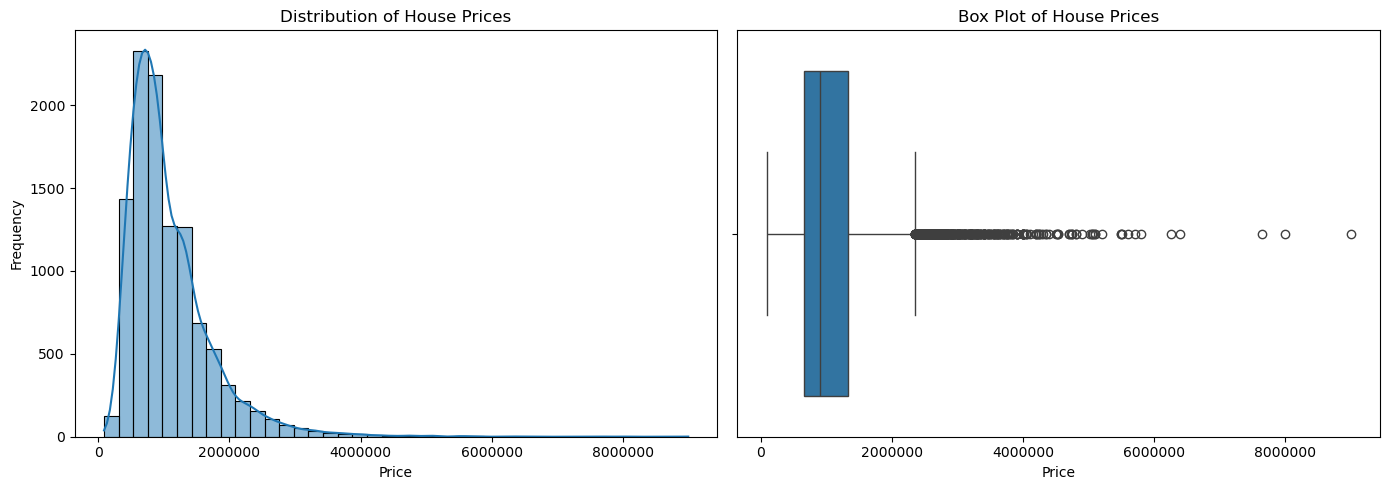

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train_df,
    x="Price",
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of House Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(style="plain", axis="x")

sns.boxplot(
    data=train_df,
    x="Price",
    ax=axes[1]
)

axes[1].set_title("Box Plot of House Prices")
axes[1].set_xlabel("Price")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
figures_path = project_root / "results" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "price_distribution_and_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Observation

The histogram confirms that house prices are strongly right-skewed, with most observations concentrated in the lower and middle price ranges and a long upper tail extending to 9,000,000. The box plot identifies numerous high-price observations beyond the upper whisker. These observations are statistical outliers, but they are not automatically data errors because they may represent genuine luxury properties. They will be quantified and investigated before any treatment decision is made.

## 8. Quantify Potential Target Outliers

The Interquartile Range (IQR) method is used to quantify unusually low or high house prices. Values outside 1.5 times the IQR are treated as potential statistical outliers for investigation, not automatically as data errors.

In [11]:
q1 = train_df["Price"].quantile(0.25)
q3 = train_df["Price"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

lower_outliers = (train_df["Price"] < lower_bound).sum()
upper_outliers = (train_df["Price"] > upper_bound).sum()

total_outliers = lower_outliers + upper_outliers
outlier_percentage = (total_outliers / len(train_df)) * 100

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower boundary: {lower_bound:,.2f}")
print(f"Upper boundary: {upper_bound:,.2f}")
print(f"Lower-price potential outliers: {lower_outliers:,}")
print(f"Upper-price potential outliers: {upper_outliers:,}")
print(f"Total potential outliers: {total_outliers:,}")
print(f"Potential outlier percentage: {outlier_percentage:.2f}%")

Q1: 650,000.00
Q3: 1,328,000.00
IQR: 678,000.00
Lower boundary: -367,000.00
Upper boundary: 2,345,000.00
Lower-price potential outliers: 0
Upper-price potential outliers: 496
Total potential outliers: 496
Potential outlier percentage: 4.57%
